In [1]:
import matplotlib.pyplot as plt
import numpy as np

from block_encoding import generate_laplacian_block_encoding, get_circuit_unitary, prepare_empty_block_encoding_circuit

In [2]:
def v1_vec(nq):
    x = np.arange(2**nq) / 2**nq

    return np.sin(2 * np.pi * x)

def v2_vec(nq):
    x = np.arange(2**nq) / 2**nq

    return np.sin(6 * np.pi * x)

def actual_laplacian(v_vec):
    h = 1 / len(v_vec)

    vals = []

    for i in range(len(v_vec)):
        up = (i+1) % len(v_vec)
        down = i - 1

        vals.append(v_vec[up] - 2 * v_vec[i] + v_vec[down])

    return np.array(vals) / h**2

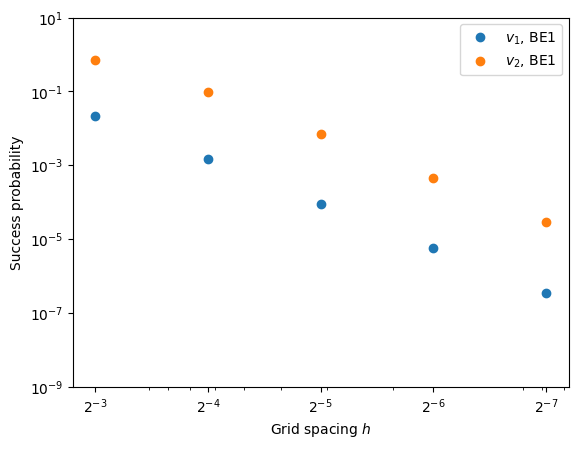

In [35]:
nqs = list([i] for i in range(3, 8))
deltas = list([2**(-nq) for nq in nqs[i]] for i in range(len(nqs)))
prob_success_v1_be1 = []
prob_success_v2_be1 = []

for i in range(len(nqs)):
    v = v1_vec(nqs[i][0])
    v_normed = v / np.linalg.norm(v)
    qc = prepare_empty_block_encoding_circuit(nqs[i], [v_normed])
    be = generate_laplacian_block_encoding(nqs[i], deltas=deltas[i], bcs=["periodic"])
    qc.append(be, qc.qubits)
    unitary = get_circuit_unitary(qc, nqs[i])
    prob_success_v1_be1.append(np.linalg.norm(unitary[:, 0]) ** 2)

    v = v2_vec(nqs[i][0])
    v_normed = v / np.linalg.norm(v)
    qc = prepare_empty_block_encoding_circuit(nqs[i], [v_normed])
    be = generate_laplacian_block_encoding(nqs[i], deltas=deltas[i], bcs=["periodic"])
    qc.append(be, qc.qubits)
    unitary = get_circuit_unitary(qc, nqs[i])
    prob_success_v2_be1.append(np.linalg.norm(unitary[:, 0]) ** 2)

qc.decompose().draw(output="mpl")


plt.plot(deltas, prob_success_v1_be1, "o", label="$v_1$, BE1")
plt.plot(deltas, prob_success_v2_be1, "o", label="$v_2$, BE1")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xticks([2**-i for i in range(3, 8)])
plt.yticks([10**i for i in range(-9, 2, 2)])
plt.gca().set_xticklabels([f"$2^{{-{i}}}$" for i in range(3, 8)])
plt.xlabel("Grid spacing $h$")
plt.ylabel("Success probability")
plt.legend()
plt.show()

In [17]:
actual_laplacian(v1_vec(3))

array([-1.42108547e-14, -2.65096680e+01, -3.74903320e+01, -2.65096680e+01,
       -7.10542736e-15,  2.65096680e+01,  3.74903320e+01,  2.65096680e+01])